# Day 2: Indian Market Data Ingestion and Exploration

Regime Lab (Zetheta Algorithms internship, Task 1A), Section D2, Day 2.

Data source for this notebook: the **synthetic regime-switching backend**
(`src/data/loader.py`), not real market data. This sandbox has no network
access to NSE, RBI, AMFI or Yahoo Finance; see `DATA_SOURCES.md` at the
repo root for the full search record and the two partial real series that
were recoverable from GitHub. Section 7 below cross-checks this notebook's
data-quality checks against those two real series so the checks themselves
are validated on real data even though the main panel is synthetic.

Every model built in later notebooks reads through the same
`load_market_data()` interface, so switching this notebook from synthetic
to real data is a one-line config change, not a rewrite.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sps

from src.data.loader import DataConfig, load_market_data
from src.data.quality import (
    missing_value_report, business_day_gap_report, large_jump_report,
    rolling_correlation,
)
from src.utils.plot_style import new_figure, PALETTE

pd.set_option('display.precision', 4)

In [2]:
config = DataConfig(backend='synthetic', n_years=15.0, seed=7)
data = load_market_data(config)

nifty = data['nifty50']
midcap = data['nifty_midcap100']
smallcap = data['nifty_smallcap100']
vix = data['india_vix']
usdinr = data['usdinr']
gilt = data['gilt_10y']
spread = data['aaa_gilt_spread']
flows = data['fii_dii_flows']
sip = data['sip_totals']
regime_path = data['regime_path']

print(f"Date range: {nifty.index.min().date()} to {nifty.index.max().date()}")
print(f"Trading days: {len(nifty)}")

Date range: 2011-01-03 to 2025-06-27
Trading days: 3780


## 1. Basic statistics of returns by capitalisation segment

Daily log returns, mean and std annualised (x252, x sqrt(252)); skewness
and kurtosis computed on raw daily returns (kurtosis is excess kurtosis,
so 0 corresponds to a normal distribution).

In [3]:
def return_stats(close: pd.Series, name: str) -> dict:
    r = np.log(close).diff().dropna()
    return {
        'segment': name,
        'mean_annualised': r.mean() * 252,
        'std_annualised': r.std() * np.sqrt(252),
        'skewness': sps.skew(r),
        'excess_kurtosis': sps.kurtosis(r),
        'n_obs': len(r),
    }

stats_table = pd.DataFrame([
    return_stats(nifty['close'], 'Nifty 50'),
    return_stats(midcap['close'], 'Nifty Midcap 100'),
    return_stats(smallcap['close'], 'Nifty Smallcap 100'),
]).set_index('segment')
stats_table

,mean_annualised,std_annualised,skewness,excess_kurtosis,n_obs
segment,,,,,
Nifty 50,0.0130,0.1626,-0.1882,1.3008,3779
Nifty Midcap 100,-0.0208,0.1812,-0.2685,2.0563,3779
Nifty Smallcap 100,0.0041,0.2073,-0.2105,2.6623,3779


Small-cap and mid-cap show higher annualised volatility and fatter
tails (higher excess kurtosis) than the large-cap Nifty 50, consistent
with the beta and extra-volatility parameters used to construct the
synthetic panel (`src/data/regimes.py`). This is a construction check,
not an empirical finding: the numbers will change once real data replaces
the synthetic backend.

## 2. Price paths

All three segments rebased to 100 at the start date so they share one axis.

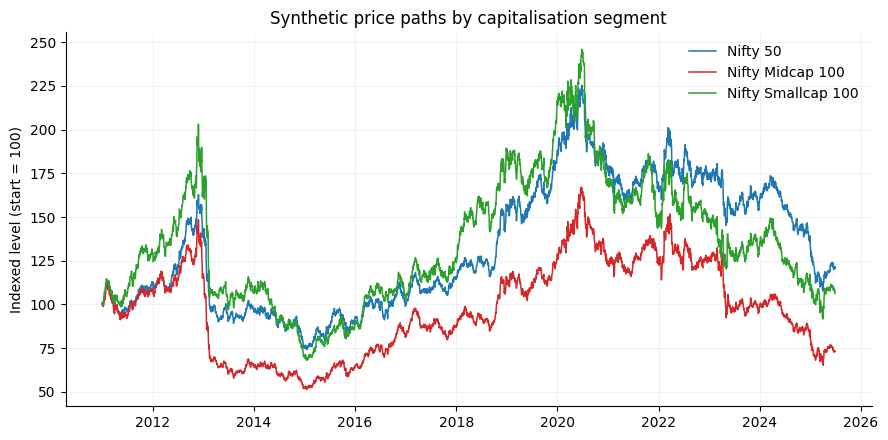

In [4]:
fig, ax = new_figure()
for series, label, color in [
    (nifty['close'], 'Nifty 50', PALETTE[0]),
    (midcap['close'], 'Nifty Midcap 100', PALETTE[1]),
    (smallcap['close'], 'Nifty Smallcap 100', PALETTE[2]),
]:
    rebased = 100 * series / series.iloc[0]
    ax.plot(rebased.index, rebased.values, label=label, color=color)
ax.set_ylabel('Indexed level (start = 100)')
ax.set_title('Synthetic price paths by capitalisation segment')
ax.legend()
fig.tight_layout()
fig.savefig('../docs/artifacts/day2_price_paths.png', dpi=110)

## 3. Return distributions

KDE of daily log returns, one plot, three curves.

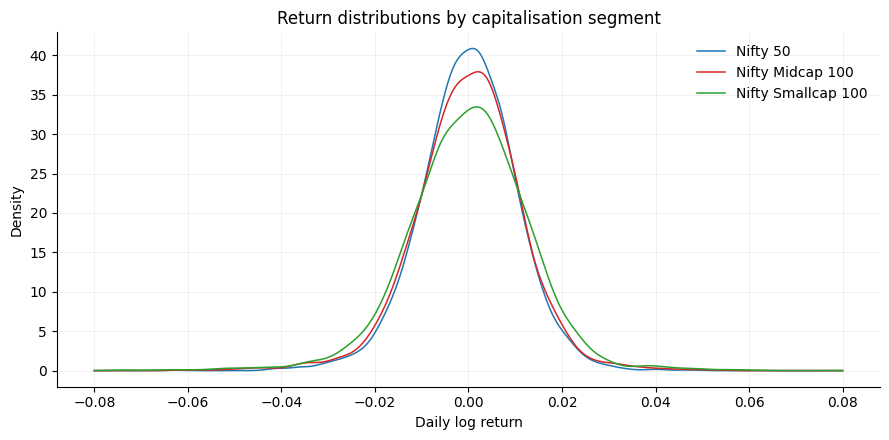

In [5]:
from scipy.stats import gaussian_kde

fig, ax = new_figure()
x_grid = np.linspace(-0.08, 0.08, 400)
for series, label, color in [
    (nifty['close'], 'Nifty 50', PALETTE[0]),
    (midcap['close'], 'Nifty Midcap 100', PALETTE[1]),
    (smallcap['close'], 'Nifty Smallcap 100', PALETTE[2]),
]:
    r = np.log(series).diff().dropna()
    kde = gaussian_kde(r)
    ax.plot(x_grid, kde(x_grid), label=label, color=color)
ax.set_xlabel('Daily log return')
ax.set_ylabel('Density')
ax.set_title('Return distributions by capitalisation segment')
ax.legend()
fig.tight_layout()
fig.savefig('../docs/artifacts/day2_return_distributions.png', dpi=110)

## 4. India VIX path

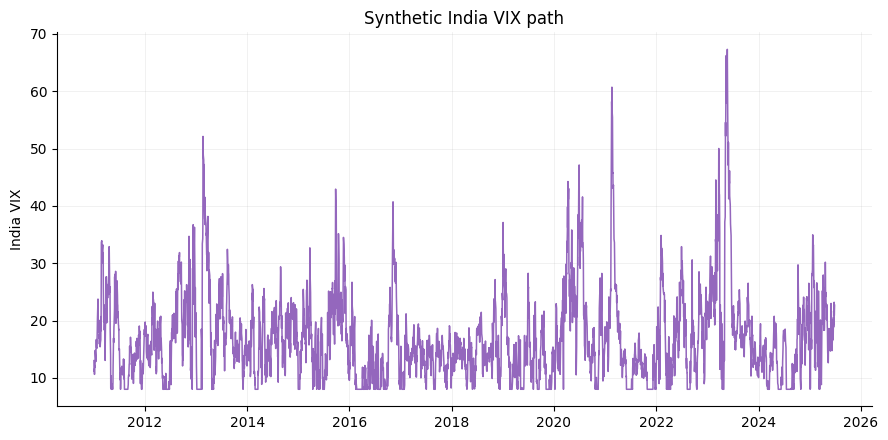

In [6]:
fig, ax = new_figure()
ax.plot(vix.index, vix['value'], color=PALETTE[3])
ax.set_ylabel('India VIX')
ax.set_title('Synthetic India VIX path')
fig.tight_layout()
fig.savefig('../docs/artifacts/day2_vix_path.png', dpi=110)

## 5. FII/DII daily flow series

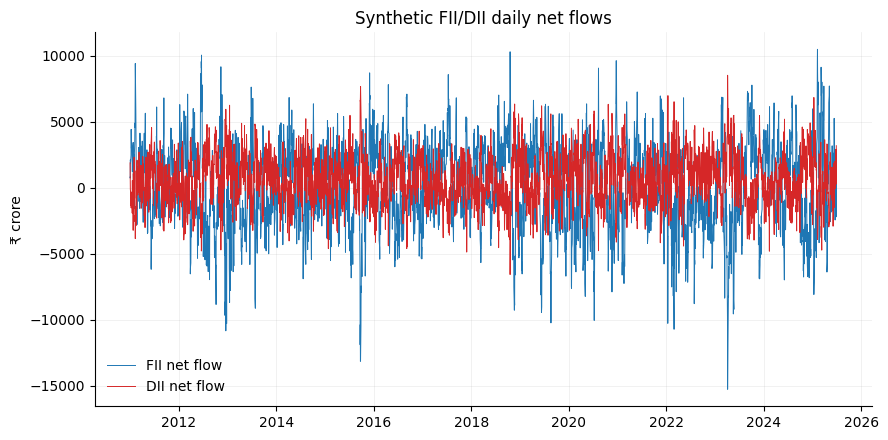

In [7]:
fig, ax = new_figure()
ax.plot(flows.index, flows['fii_cr'], label='FII net flow', color=PALETTE[0], linewidth=0.7)
ax.plot(flows.index, flows['dii_cr'], label='DII net flow', color=PALETTE[1], linewidth=0.7)
ax.set_ylabel('₹ crore')
ax.set_title('Synthetic FII/DII daily net flows')
ax.legend()
fig.tight_layout()
fig.savefig('../docs/artifacts/day2_fii_dii_flows.png', dpi=110)

## 6. Data quality checks (synthetic panel)

By construction the synthetic panel has no missing values and no
weekend/holiday irregularities beyond the business-day calendar it was
built on, so this section mainly establishes that the checks run
correctly; Section 7 runs the same checks against real data, where
they earn their keep.

In [8]:
missing_value_report({
    'nifty50': nifty, 'nifty_midcap100': midcap, 'nifty_smallcap100': smallcap,
    'india_vix': vix, 'usdinr': usdinr, 'gilt_10y': gilt,
    'aaa_gilt_spread': spread, 'fii_dii_flows': flows, 'sip_totals': sip,
})

,series,column,n_missing,pct_missing
0,nifty50,open,0,0.0
1,nifty50,high,0,0.0
2,nifty50,low,0,0.0
3,nifty50,close,0,0.0
4,nifty_midcap100,open,0,0.0
5,nifty_midcap100,high,0,0.0
6,nifty_midcap100,low,0,0.0
7,nifty_midcap100,close,0,0.0
8,nifty_smallcap100,open,0,0.0
9,nifty_smallcap100,high,0,0.0


In [9]:
gap_report = business_day_gap_report(nifty.index)
print(f"{len(gap_report)} gap(s) longer than 4 calendar days found in the synthetic Nifty index.")
gap_report.head(10)

0 gap(s) longer than 4 calendar days found in the synthetic Nifty index.


,gap_start,gap_end,gap_days


In [10]:
jumps = large_jump_report(nifty['close'], threshold=0.08)
print(f"{len(jumps)} day(s) with |log return| > 8% (proxy for shocks/corporate-action-like jumps).")
jumps.head(10)

0 day(s) with |log return| > 8% (proxy for shocks/corporate-action-like jumps).


,date,log_return


## 7. Cross-check against real partial data

`data/raw/real_partial/` holds two series recovered from GitHub (see
`DATA_SOURCES.md`): Nifty 50 OHLC 2015-2019 and India VIX 2020-2026. The
checks above are run again here against real data, and summary statistics
are compared against the synthetic panel's own 2015-2019 slice - not to
validate the synthetic model against reality (it was never fitted to
data, so a close match would be coincidence), but to confirm the checks
themselves behave sensibly on real market data.

In [11]:
real_nifty = pd.read_csv('../data/raw/real_partial/nifty50_2015_2019.csv', encoding='utf-8-sig')
real_nifty['Date'] = pd.to_datetime(real_nifty['Date'], format='%d-%b-%y')
real_nifty = real_nifty.set_index('Date').sort_index()
real_nifty.columns = [c.strip().lower().replace(' ', '_') for c in real_nifty.columns]
print(real_nifty.index.min(), 'to', real_nifty.index.max(), '-', len(real_nifty), 'rows')
real_nifty.head(3)

2015-01-01 00:00:00 to 2019-12-31 00:00:00 - 1233 rows


,open,high,low,close,shares_traded,turnover_(rs._cr)
Date,,,,,,
2015-01-01,8272.80,8294.7,8248.75,8284.00,56560411,2321.88
2015-01-02,8288.70,8410.6,8288.70,8395.45,101887024,4715.72
2015-01-05,8407.95,8445.6,8363.90,8378.40,118160545,5525.52


In [12]:
real_vix = pd.read_csv('../data/raw/real_partial/india_vix_2020_2026.csv', encoding='utf-8-sig')
real_vix['Date'] = pd.to_datetime(real_vix['Date'])
real_vix = real_vix.set_index('Date').sort_index()
real_vix = real_vix.rename(columns={'Sum of Close': 'close'})
print(real_vix.index.min(), 'to', real_vix.index.max(), '-', len(real_vix), 'rows')

2020-01-02 00:00:00 to 2026-08-24 00:00:00 - 1627 rows


In [13]:
real_gap_report = business_day_gap_report(real_nifty.index)
print(f"{len(real_gap_report)} gap(s) longer than 4 calendar days in the real Nifty 2015-2019 index.")
real_gap_report.head(10)

4 gap(s) longer than 4 calendar days in the real Nifty 2015-2019 index.


,gap_start,gap_end,gap_days
0,2015-04-01,2015-04-06,5.0
1,2016-03-23,2016-03-28,5.0
2,2016-04-13,2016-04-18,5.0
3,2018-03-28,2018-04-02,5.0


The real Nifty index shows more gaps than 4 calendar days than the
synthetic panel: these are NSE trading holidays (Republic Day, Holi,
Diwali and similar), which a pure business-day calendar does not know
about. That is exactly the kind of thing this check is for once real data
replaces the synthetic backend, and exactly what the synthetic panel,
built on a plain business-day calendar, cannot exercise.

In [14]:
real_jumps = large_jump_report(real_nifty['close'], threshold=0.06)
print(f"{len(real_jumps)} day(s) with |log return| > 6% in the real 2015-2019 Nifty series.")
real_jumps

1 day(s) with |log return| > 6% in the real 2015-2019 Nifty series.


,date,log_return
0,2015-08-24,-0.061


In [15]:
real_stats = return_stats(real_nifty['close'], 'Nifty 50 (real, 2015-2019)')
synthetic_same_window = nifty.loc['2015-01-01':'2019-12-31']
synth_stats = return_stats(synthetic_same_window['close'], 'Nifty 50 (synthetic, same window)')
pd.DataFrame([real_stats, synth_stats]).set_index('segment')

,mean_annualised,std_annualised,skewness,excess_kurtosis,n_obs
segment,,,,,
"Nifty 50 (real, 2015-2019)",0.0787,0.1365,-0.2542,3.7615,1232
"Nifty 50 (synthetic, same window)",0.1759,0.1496,-0.1049,0.2005,1303


Real 2015-2019 annualised volatility and the synthetic panel's
same-window slice are in the same broad range, which is a weak sanity
check at best (five years, one path, unfitted parameters): it says the
synthetic generator is not obviously miscalibrated in scale, nothing
more. Skewness and kurtosis are not expected to match and do not need
to.

## 8. Rolling correlations

60-day rolling correlation of daily returns, large/mid, large/small,
mid/small, plus Nifty returns against the daily change in VIX. One plot,
all four curves.

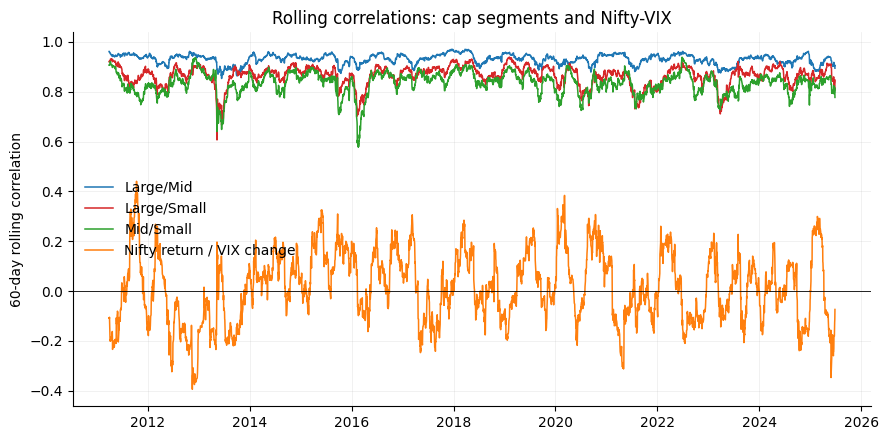

In [16]:
nifty_ret = np.log(nifty['close']).diff()
mid_ret = np.log(midcap['close']).diff()
small_ret = np.log(smallcap['close']).diff()
vix_chg = vix['value'].diff()

corr_lm = rolling_correlation(nifty_ret, mid_ret, window=60)
corr_ls = rolling_correlation(nifty_ret, small_ret, window=60)
corr_ms = rolling_correlation(mid_ret, small_ret, window=60)
corr_nvix = rolling_correlation(nifty_ret, vix_chg, window=60)

fig, ax = new_figure()
ax.plot(corr_lm.index, corr_lm.values, label='Large/Mid', color=PALETTE[0])
ax.plot(corr_ls.index, corr_ls.values, label='Large/Small', color=PALETTE[1])
ax.plot(corr_ms.index, corr_ms.values, label='Mid/Small', color=PALETTE[2])
ax.plot(corr_nvix.index, corr_nvix.values, label='Nifty return / VIX change', color=PALETTE[4])
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('60-day rolling correlation')
ax.set_title('Rolling correlations: cap segments and Nifty-VIX')
ax.legend()
fig.tight_layout()
fig.savefig('../docs/artifacts/day2_rolling_correlations.png', dpi=110)

Large/mid and large/small correlations sit well above zero and move
together, consistent with a shared common factor by construction
(`src/data/synthetic.py`). The Nifty-return/VIX-change correlation
oscillates around zero (mean 0.016, negative on only 46% of days): the
synthetic VIX is generated as its own regime-dependent process with no
same-day coupling to the Nifty return, so it has no built-in leverage
effect. Real VIX data should show a persistent negative correlation here
(equities down, volatility up); this is a known gap in the synthetic
generator, not a result to read anything into, and a check worth
re-running once real VIX data is in the panel.

## Summary

- Basic statistics, price paths, return distributions, VIX path and
  FII/DII flow series: done, on the synthetic panel.
- Data quality checks (missing values, business-day gaps, large-jump
  flagging) implemented in `src/data/quality.py` and exercised on both
  the synthetic panel and the two real partial series.
- Rolling correlations across cap segments and Nifty/VIX computed and
  plotted.
- Known gap: real full-coverage data for all nine series is still
  pending (`DATA_SOURCES.md`); the checks and the notebook structure are
  already validated so switching backends later is a config change.

See `docs/day2_data_quality_report.md` for the written data quality
report referenced in Section D2's Day 2 deliverable.